In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from inputs_for_plots import *

In [19]:
def level_of_confounding(mm):
    I, J = mm.shape
    mm = mm.values
    treatment_effec = mm[I-1, J-2]
    confounder_effect_on_treatment = mm[I-2,0]
    total_confounder_effect = mm[I-1,0]
    confounder_edge = total_confounder_effect - treatment_effec*confounder_effect_on_treatment
    return np.abs(confounder_edge*confounder_effect_on_treatment)

In [43]:
# iv p value true source
p_values1 = pd.read_csv(f"../IV_test_results/increased_confounding/LDAG_true_source_conf_{1}.csv", index_col=0)
p_values3 = pd.read_csv(f"../IV_test_results/increased_confounding/LDAG_true_source_conf_{3}.csv", index_col=0)
p_values6 = pd.read_csv(f"../IV_test_results/increased_confounding/LDAG_true_source_conf_{6}.csv", index_col=0)


In [49]:
# calculate level of confounding
cn1 = []
cn3 = []
cn6 = []

for i in range(100):
    mm1 = pd.read_csv(f"../increase_conf/mixing_matrix/true_mixing_large_conf_1_{i}.csv", index_col=None)
    mm3 = pd.read_csv(f"../increase_conf/mixing_matrix/true_mixing_large_conf_3_{i}.csv", index_col=None)
    mm6 = pd.read_csv(f"../increase_conf/mixing_matrix/true_mixing_large_conf_6_{i}.csv", index_col=None)
    cn1.append(level_of_confounding(mm1))
    cn3.append(level_of_confounding(mm3))
    cn6.append(level_of_confounding(mm6))


In [50]:
p_values1

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10
1,0,0.000,0.540,0.568,0.380,0.472,0.516,0.368,0.720,0.004
2,1,0.000,0.328,0.508,0.468,0.308,0.440,0.412,0.000,0.000
3,2,1.000,0.784,0.416,0.620,0.996,0.492,0.644,0.976,0.000
4,3,0.000,0.396,0.580,0.516,0.640,0.620,0.324,0.004,0.000
5,4,0.488,0.548,0.544,0.404,0.480,0.556,0.480,0.932,0.000
...,...,...,...,...,...,...,...,...,...,...
96,95,0.000,0.408,0.388,0.440,0.392,0.536,0.620,1.000,0.000
97,96,0.000,0.492,0.448,0.364,0.584,0.568,0.576,0.872,0.000
98,97,0.016,0.532,0.540,0.516,0.560,0.456,0.488,0.544,0.020
99,98,0.964,0.464,0.500,0.560,0.456,0.376,0.428,0.000,0.000


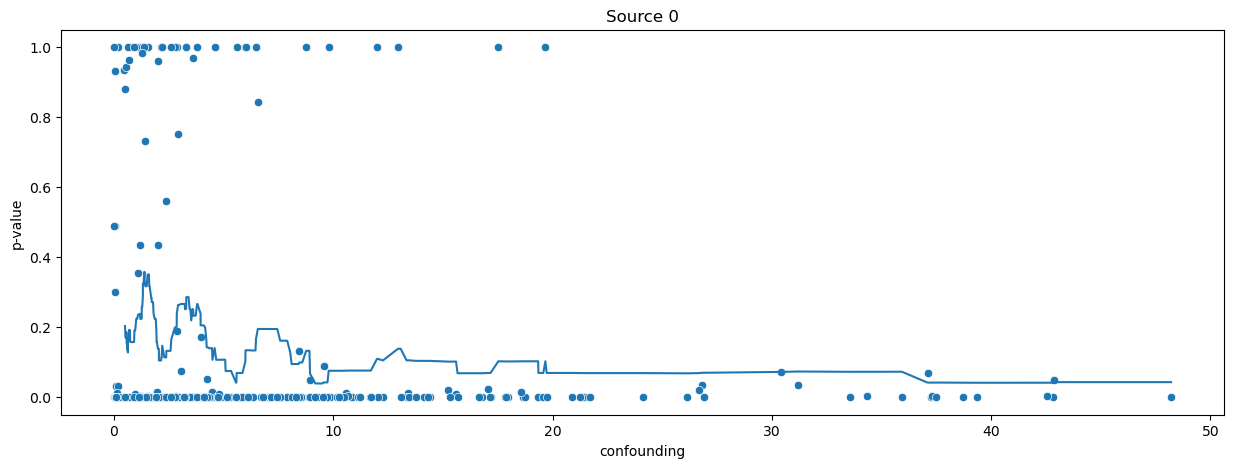

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confounding_level_vs_pvalue(source_index):
    fig, ax = plt.subplots(1, 1, figsize=(15, 5))

    df_long = pd.concat([pd.DataFrame({"p-value": p_values1.iloc[:,source_index+1].values, "confounding": cn1}),
                            pd.DataFrame({"p-value": p_values3.iloc[:,source_index+1].values, "confounding": cn3}),
                            pd.DataFrame({"p-value": p_values6.iloc[:,source_index+1].values, "confounding": cn6})])
    sns.scatterplot(data=df_long, x="confounding", y="p-value", ax=ax)
# moving average
    df_long = df_long.sort_values("confounding").reset_index(drop=True)
    df_long["p-value"] = df_long["p-value"].rolling(window=30).mean()
    sns.lineplot(data=df_long, x="confounding", y="p-value", ax=ax)
    
    ax.set_title(f"Source {source_index}")

    plt.show()

plot_confounding_level_vs_pvalue(0)